In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("../beam_search_summary.csv")
df

,dataset,beam_width,k,avg_edges_1.0,train_relevant_1.0,train_seen_1.0,train_expanded_1.0,avg_edges_0.995,train_relevant_0.995,train_seen_0.995,...,train_seen_0.815,train_expanded_0.815,avg_edges_0.81,train_relevant_0.81,train_seen_0.81,train_expanded_0.81,avg_edges_0.805,train_relevant_0.805,train_seen_0.805,train_expanded_0.805
0,mnist,1,1,19.637517,1.0000,154.5700,8.9100,9.319767,0.4100,87.2400,...,15.4200,6.3900,2.724333,0.0100,15.4200,6.3400,2.689333,0.0100,15.8400,6.6000
1,mnist,1,10,19.637517,1.0000,154.5700,8.9100,9.319767,0.4900,87.2400,...,15.4200,6.3900,2.724333,0.0100,15.4200,6.3400,2.689333,0.0100,15.8400,6.6000
2,mnist,1,100,19.637517,1.0000,154.5700,8.9100,9.319767,0.6200,87.2400,...,15.4200,6.3900,2.724333,0.0500,15.4200,6.3400,2.689333,0.0500,15.8400,6.6000
3,mnist,2,1,19.637517,1.0000,167.6400,9.6500,9.319767,0.7200,114.3800,...,27.5300,11.1600,2.724333,0.0300,27.6200,11.1200,2.689333,0.0400,28.5200,11.5100
4,mnist,2,10,19.637517,2.0000,167.6400,9.6500,9.319767,1.5900,114.3800,...,27.5300,11.1600,2.724333,0.1100,27.6200,11.1200,2.689333,0.1300,28.5200,11.5100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,glove25,128,10,50.408023,9.9888,5844.9188,133.0049,7.294107,8.1813,1159.4052,...,390.3806,181.7411,1.927580,0.6206,383.8036,181.9747,1.907492,0.5442,377.4968,181.8186
146,glove25,128,100,50.408023,97.1300,5844.9188,133.0049,7.294107,74.5897,1159.4052,...,390.3806,181.7411,1.927580,6.3824,383.8036,181.9747,1.907492,5.6570,377.4968,181.8186
147,glove25,256,1,50.408023,1.0000,10479.2726,260.6352,7.294107,0.7448,1979.7641,...,681.4677,342.4708,1.927580,0.0554,669.7409,342.2988,1.907492,0.0490,659.9581,342.4923
148,glove25,256,10,50.408023,9.9988,10479.2726,260.6352,7.294107,8.5284,1979.7641,...,681.4677,342.4708,1.927580,1.0380,669.7409,342.2988,1.907492,0.9382,659.9581,342.4923


In [ ]:
import re

plt.style.use('default')

TRAIN_COLOR = 'black'

for _, row in df.iterrows():
    coverages = sorted(
        [float(re.search(r'avg_edges_(.+)', c).group(1))
         for c in df.columns if c.startswith('avg_edges_')],
        reverse=True
    )

    avg_edges      = [row[f'avg_edges_{v}']      for v in coverages]
    train_precision   = [row[f'train_relevant_{v}'] / min(row['beam_width'], 100) for v in coverages]
    train_seen     = [row[f'train_seen_{v}']     for v in coverages]
    train_expanded = [row[f'train_expanded_{v}'] for v in coverages]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"{row['dataset']}, beam width = {row['beam_width']}", fontsize=14, fontweight='bold')

    plot_specs = [
        {'ylabel': 'Avg. Precision',   'train_y': train_precision},
        {'ylabel': 'Avg. Edges',    'train_y': avg_edges},
        {'ylabel': 'Avg. Seen',     'train_y': train_seen},
        {'ylabel': 'Avg. Expanded', 'train_y': train_expanded},
    ]

    for ax, spec in zip(axes, plot_specs):
        ax.plot(coverages, spec['train_y'], color=TRAIN_COLOR, linewidth=1.5)
        for xi, yi in zip(coverages, spec['train_y']):
            ax.scatter(xi, yi, color=TRAIN_COLOR, s=10, zorder=5, linewidths=1.5)
            # ax.text(xi, yi, f'{xi}', ha='center', va='center', fontsize=5, color=TRAIN_COLOR, zorder=3)
        ax.set_xlabel('Coverage (navigability %)')
        ax.set_ylabel(spec['ylabel'])

    plt.tight_layout()
    plt.show()


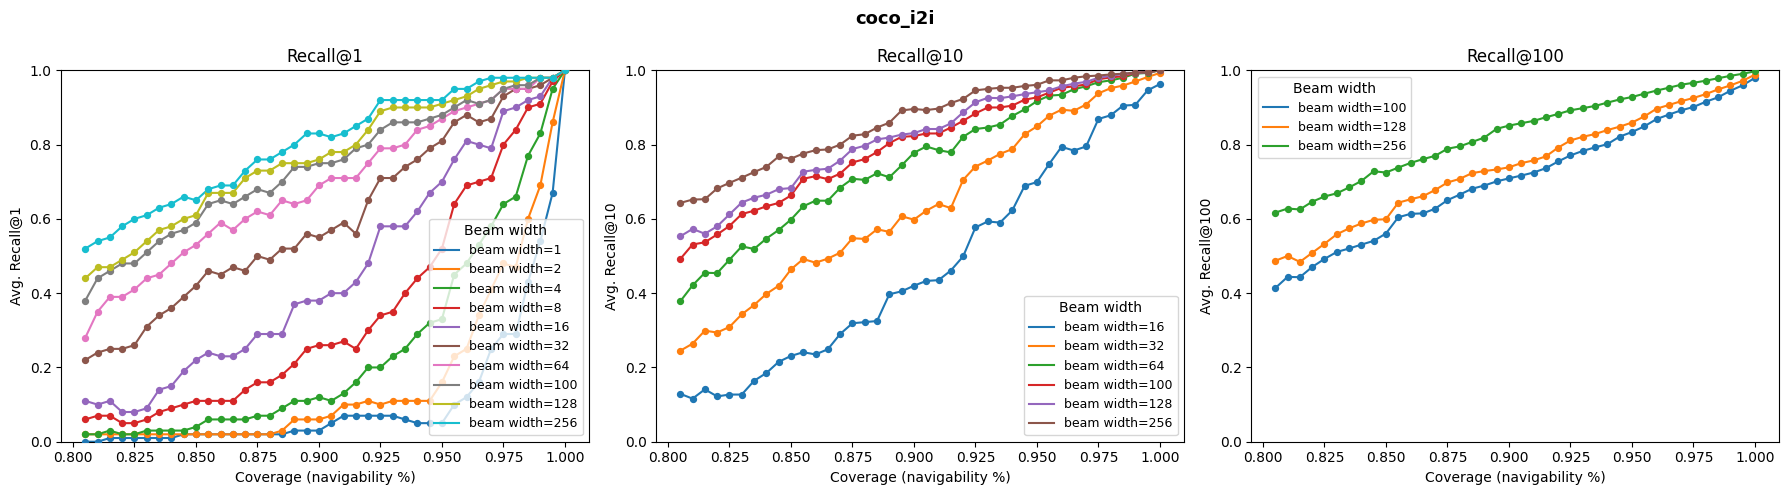

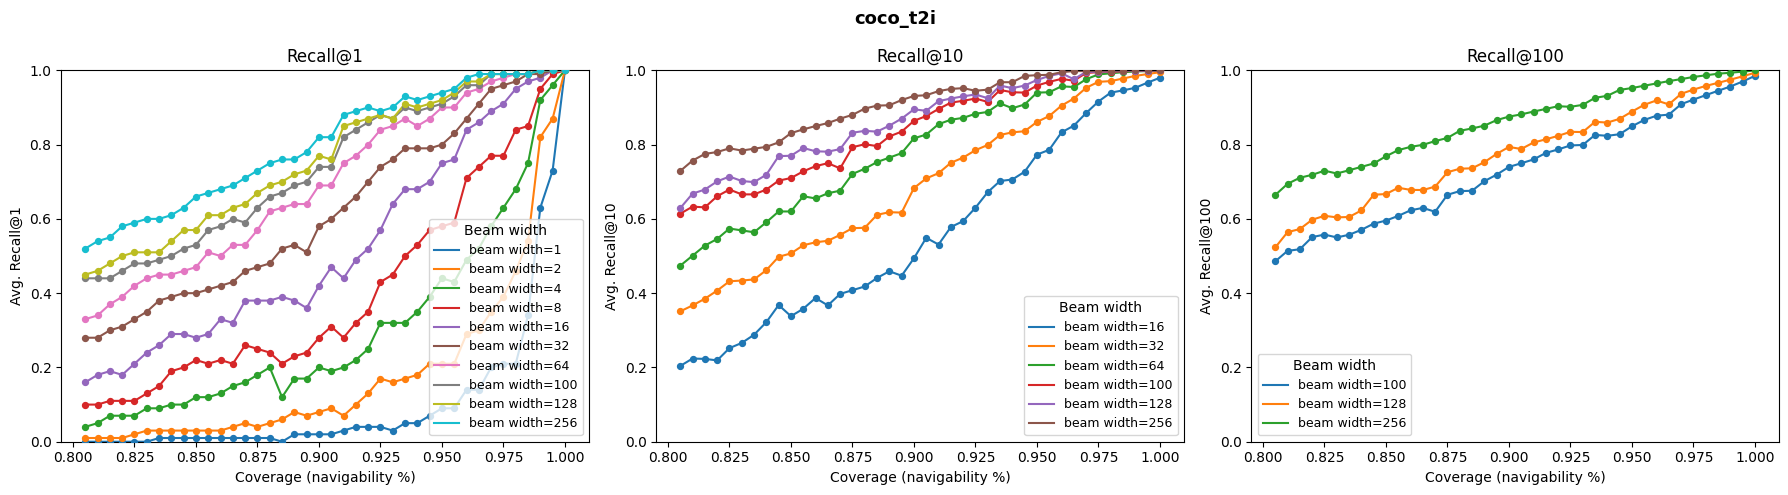

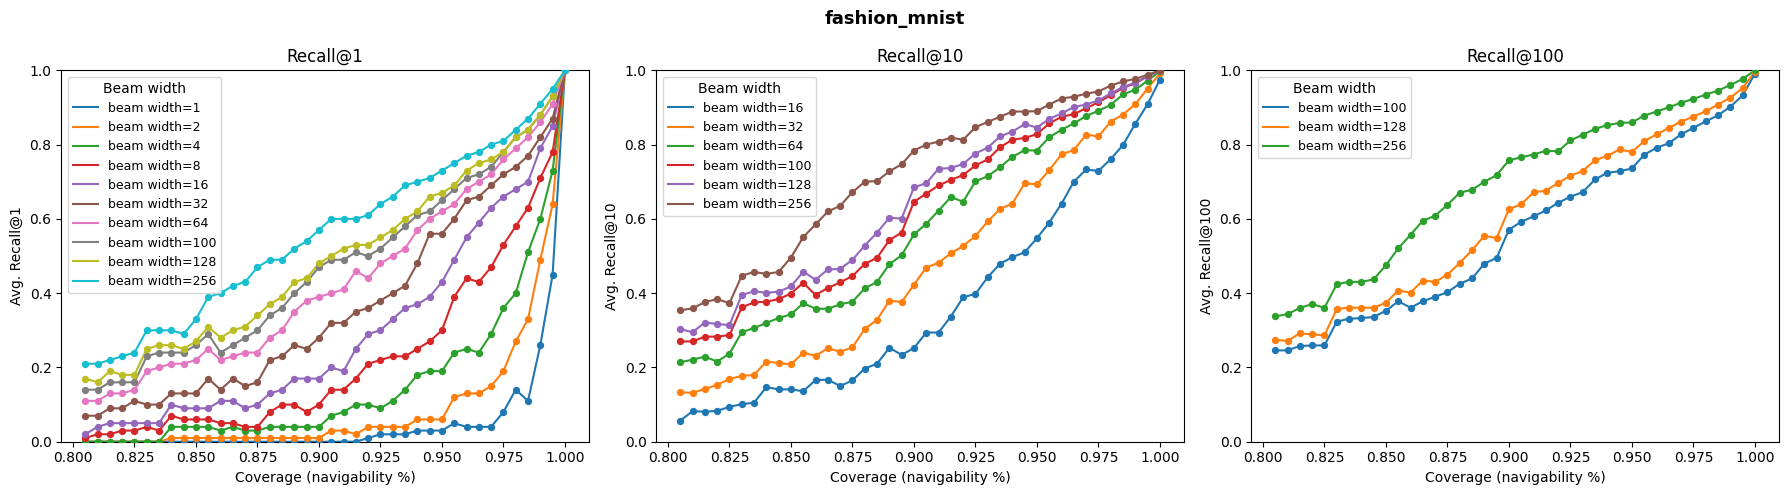

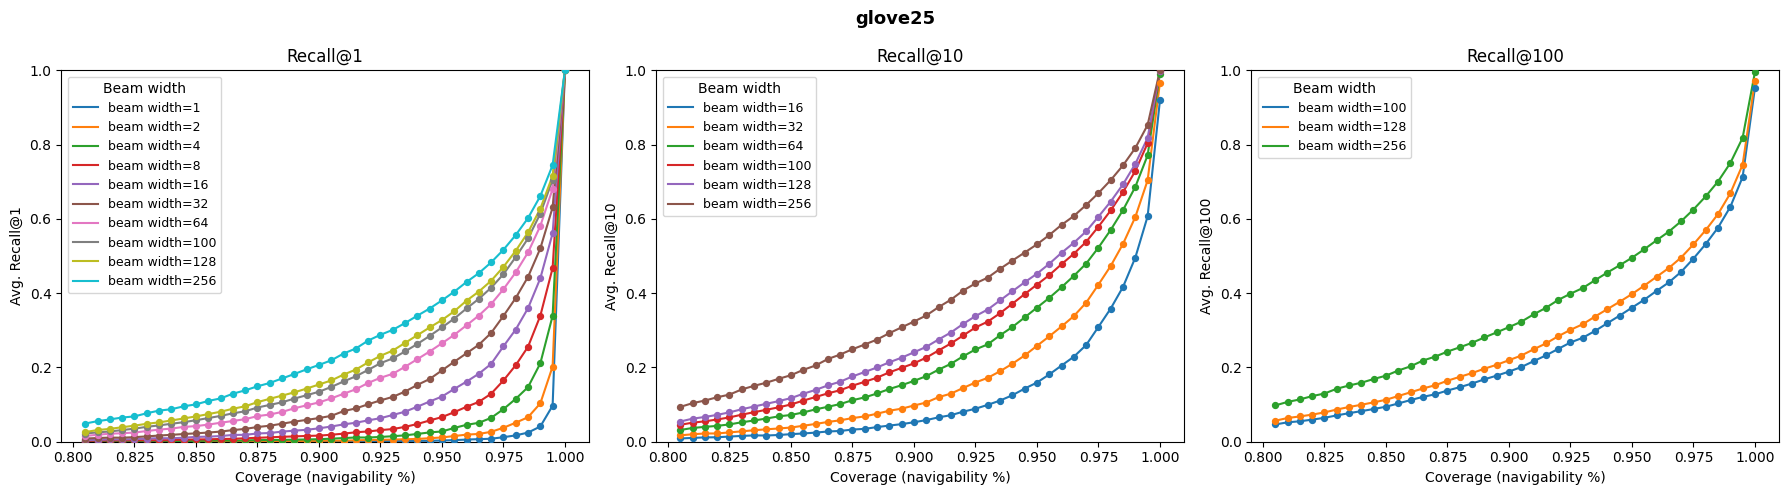

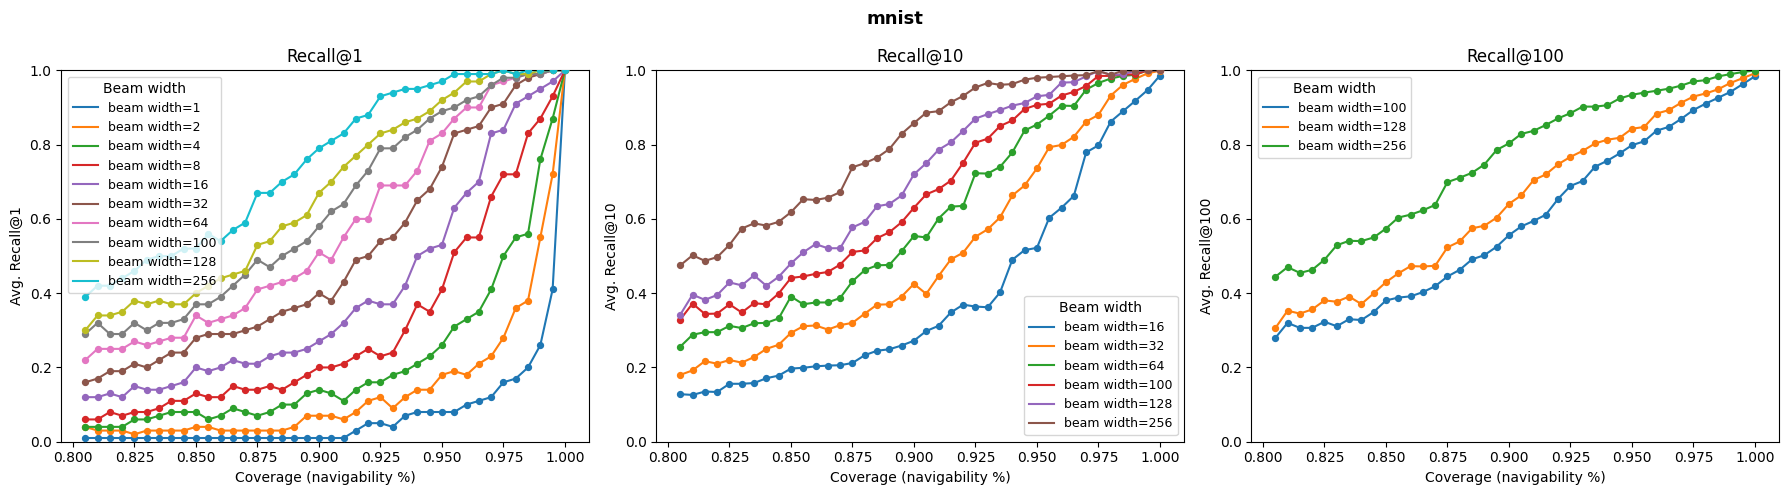

In [29]:
import re
import matplotlib.cm as cm

plt.style.use('default')

coverages = sorted(
    [float(re.search(r'avg_edges_(.+)', c).group(1))
     for c in df.columns if c.startswith('avg_edges_')],
    reverse=True
)

RECALL_KS = sorted(df['k'].unique())

for dataset, ds_df in df.groupby('dataset'):
    valid_ks = [k for k in RECALL_KS if not ds_df[(ds_df['k'] == k) & (ds_df['beam_width'] >= k)].empty]
    if not valid_ks:
        continue

    fig, axes = plt.subplots(1, len(valid_ks), figsize=(6 * len(valid_ks), 5))
    if len(valid_ks) == 1:
        axes = [axes]
    fig.suptitle(dataset, fontsize=13, fontweight='bold')

    for ax, k in zip(axes, valid_ks):
        k_df = ds_df[(ds_df['k'] == k) & (ds_df['beam_width'] >= k)]

        beam_widths = sorted(k_df['beam_width'].unique())
        colors      = cm.tab10.colors[:len(beam_widths)]
        color_map   = dict(zip(beam_widths, colors))

        for _, row in k_df.iterrows():
            bw    = row['beam_width']
            ys    = [row[f'train_relevant_{v}'] / row['k'] for v in coverages]
            ax.plot(coverages, ys, color=color_map[bw], linewidth=1.5, label=f'beam width={bw}')
            ax.scatter(coverages, ys, color=color_map[bw], s=18, zorder=5)

        ax.set_title(f'Recall@{k}')
        ax.set_xlabel('Coverage (navigability %)')
        ax.set_ylabel(f'Avg. Recall@{k}')
        ax.set_ylim(0,1)
        ax.legend(title='Beam width', fontsize=9)

    plt.tight_layout()
    plt.show()